# DK1 Electricity Price Forecasting — EDA on `hourly_features.csv`

This notebook replicates `01_eda.ipynb` using the pre-merged `hourly_features.csv` feature matrix
instead of the individual raw loaders.  Every raw signal is already aligned to the UTC hourly index.

| Rank | Variable | Key source |
|------|----------|------------|
| 1 | Wind power production | Liu 2023; Jónsson 2013 |
| 2 | Lagged prices (24h, 168h) | Lago 2021; Uniejewski 2018 |
| 3 | Cross-border flows (DK1↔DE) | Li & Becker 2021; Liu 2023 |
| 4 | Load / consumption | Becker & Blatt 2020 |
| 5 | Commodity prices (TTF, EUA) | Tschora 2022; Trebbien 2023 |
| 6 | Calendar effects | Uniejewski 2018 |
| 7 | Climate (wind speed, temperature) | Karabiber 2019 |

> **Note:** The CSV provides only *aggregate* cross-border flows (`gross_import_mw`, `gross_export_mw`, `net_import_mw`),
> not per-partner flows.  Sections that relied on partner-level data are adapted accordingly.

## 0 · Setup

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

from epf.eda import descriptive, temporal, relationships

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 120

DATA = Path("..") / "data"

## 1 · Load dataset

In [8]:
raw = pd.read_csv(
    DATA / "hourly_features.csv",
    parse_dates=["ts_utc"],
    index_col="ts_utc",
)
raw.index.name = "ts_utc"
raw.index = raw.index.tz_localize("UTC")

print(f"Shape        : {raw.shape}")
print(f"Date range   : {raw.index.min()} → {raw.index.max()}")
print(f"Columns ({len(raw.columns)}): {list(raw.columns)}")

Shape        : (96144, 35)
Date range   : 2014-12-31 23:00:00+00:00 → 2025-12-19 22:00:00+00:00
Columns (35): ['date_utc', 'day_ahead_price_eur_mwh', 'actual_load_mw', 'day_ahead_load_forecast_mw', 'solar_day_ahead_mw', 'solar_intraday_mw', 'solar_current_mw', 'solar_actual_mw', 'wind_onshore_day_ahead_mw', 'wind_onshore_intraday_mw', 'wind_onshore_current_mw', 'wind_onshore_actual_mw', 'wind_offshore_day_ahead_mw', 'wind_offshore_intraday_mw', 'wind_offshore_current_mw', 'wind_offshore_actual_mw', 'gross_import_mw', 'gross_export_mw', 'net_import_mw', 'coal_price', 'oil_price', 'gas_price', 'eua_price', 'msci_eu', 'eurostoxx50', 'vix', 'usd_eur', 'dk_cpi', 'dk_energy_cpi', 'gdp_denmark', 'gdp_euro_area', 'tg_daily', 'rr_daily', 'ss_daily', 'fg_daily']


In [9]:
# ── Convenience aliases (mirrors 01_eda variable names) ──────────────────────
price        = raw["day_ahead_price_eur_mwh"]
load_actual  = raw["actual_load_mw"]
load_fc      = raw["day_ahead_load_forecast_mw"]
wind_on_act  = raw["wind_onshore_actual_mw"]
wind_off_act = raw["wind_offshore_actual_mw"]
solar_act    = raw["solar_actual_mw"]
net_import   = raw["net_import_mw"]   # positive = DK1 is net importer
gross_import = raw["gross_import_mw"]
gross_export = raw["gross_export_mw"]

gas  = raw["gas_price"]
eua  = raw["eua_price"]
coal = raw["coal_price"]
oil  = raw["oil_price"]

# Climate: tg_daily / fg_daily are in raw ECA&D units (0.1 °C, 0.1 m/s)
# Divide by 10 to get SI units — same as 01_eda
fg = raw["fg_daily"]   # wind speed (0.1 m/s)
tg = raw["tg_daily"]   # mean temperature (0.1 °C)

print(f"Price series : {price.index.min().date()} → {price.index.max().date()}  "
      f"({len(price):,} obs, {price.isna().mean():.1%} NaN)")
print(f"NaN summary:\n{raw.isna().mean().mul(100).round(1).to_string()}")

Price series : 2014-12-31 → 2025-12-19  (96,144 obs, 0.0% NaN)
NaN summary:
date_utc                       0.0
day_ahead_price_eur_mwh        0.0
actual_load_mw                 0.0
day_ahead_load_forecast_mw     0.0
solar_day_ahead_mw             9.5
solar_intraday_mw             57.8
solar_current_mw              46.4
solar_actual_mw                9.1
wind_onshore_day_ahead_mw      9.5
wind_onshore_intraday_mw      57.7
wind_onshore_current_mw       46.4
wind_onshore_actual_mw         9.1
wind_offshore_day_ahead_mw     9.4
wind_offshore_intraday_mw     57.8
wind_offshore_current_mw      46.4
wind_offshore_actual_mw        9.1
gross_import_mw                0.0
gross_export_mw                0.0
net_import_mw                  0.0
coal_price                    27.4
oil_price                     27.4
gas_price                     27.4
eua_price                     27.4
msci_eu                       27.4
eurostoxx50                   27.4
vix                           27.4
usd_eur       

---
## 2 · Price Series Overview

DK1 prices can go deeply negative (excess wind) and spike above 1,000 EUR/MWh during the 2021–22 energy crisis.  
The orange band marks the crisis period referenced throughout the literature.

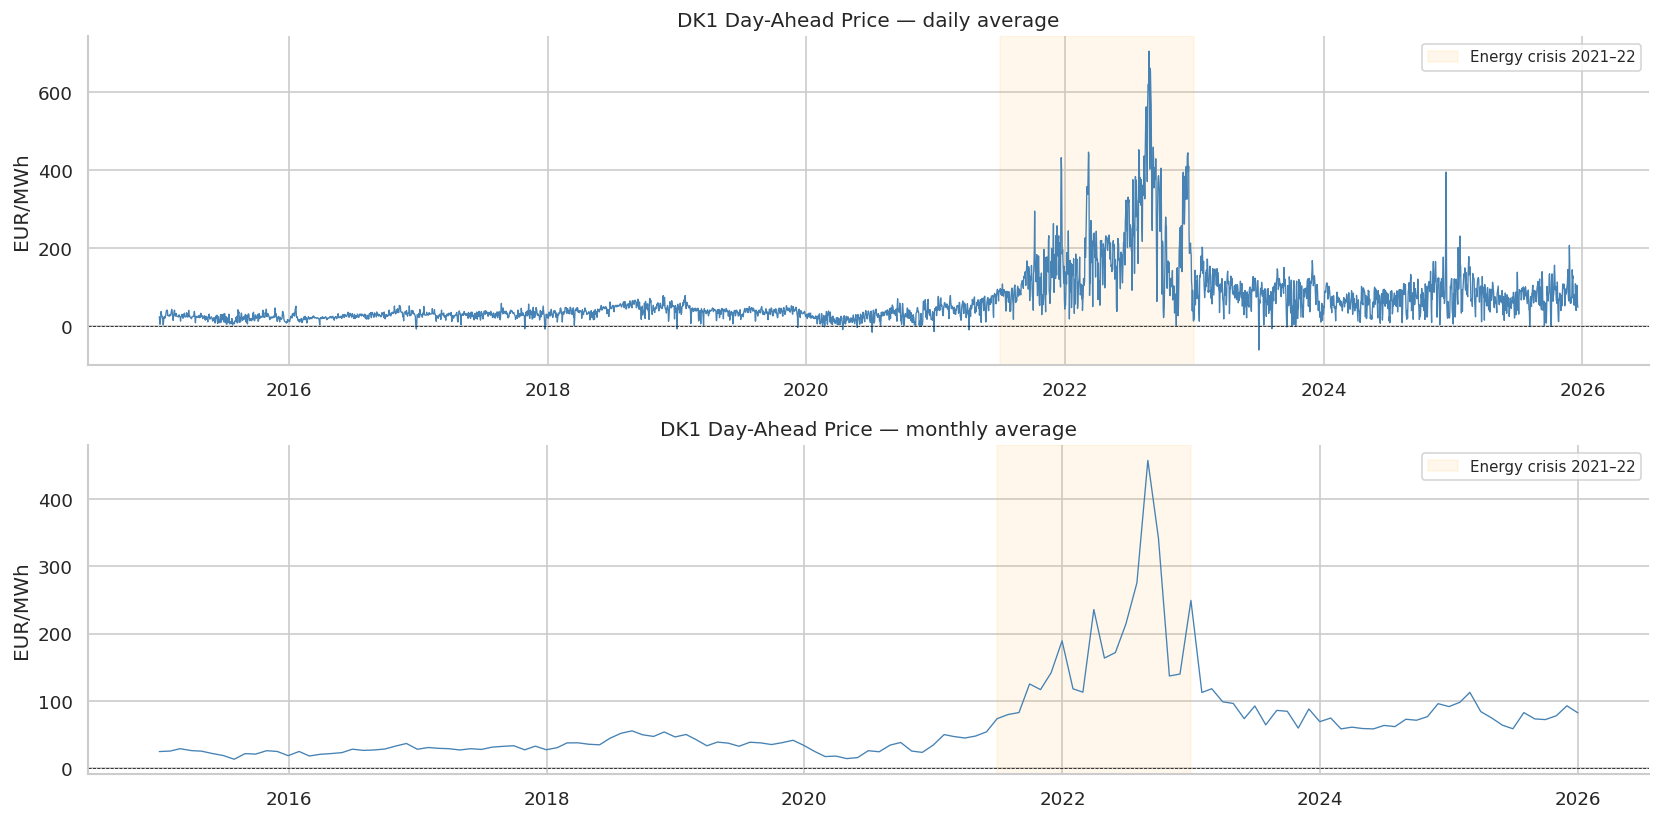

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
descriptive.plot_price_series(price, resample="D", ax=axes[0], crisis_shade=True)
descriptive.plot_price_series(price, resample="ME", ax=axes[1], crisis_shade=True)
axes[0].set_title("DK1 Day-Ahead Price — daily average")
axes[1].set_title("DK1 Day-Ahead Price — monthly average")
fig.tight_layout()

/home/clayt/Electricity-Price-Forecasting/src/epf/eda/descriptive.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: title={'center': 'Annual price distribution (whiskers = 5th–95th pct)'}, ylabel='EUR/MWh'>

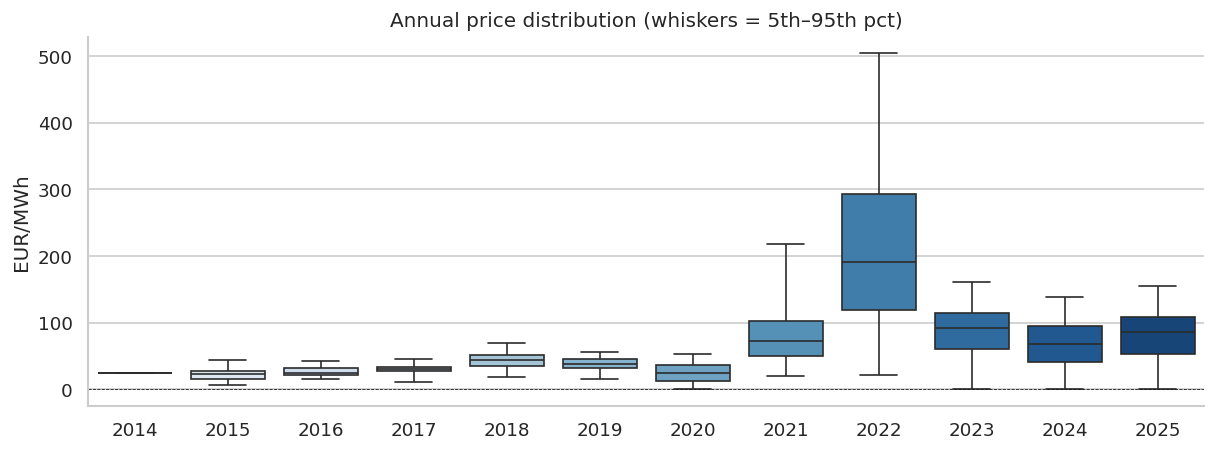

In [11]:
descriptive.plot_annual_boxplots(price)

### 2.1 Summary statistics

In [12]:
stats = descriptive.summary_stats(price)
stats.style.format("{:.2f}", subset=stats.columns[:-1]).set_caption("DK1 hourly price statistics")

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,All
N (obs),1.00,8760.00,8784.00,8760.00,8760.00,8760.00,8784.00,8760.00,8760.00,8760.00,8784.00,8471.00,96144.000000
Mean,25.02,22.89,26.67,30.08,44.05,38.49,24.99,88.14,219.03,86.83,70.64,81.06,66.560000
Median,25.02,23.68,24.78,30.12,44.18,38.75,23.86,73.26,190.62,92.04,67.90,85.66,41.080000
Std,nan,11.12,9.76,10.68,15.06,13.16,17.44,64.78,145.45,48.82,50.16,51.24,77.570000
Min,25.02,-31.41,-53.62,-50.04,-15.00,-48.29,-58.80,-43.91,-19.04,-440.10,-60.05,-38.14,-440.100000
Max,25.02,99.77,104.96,120.01,144.33,109.45,200.04,620.00,871.00,524.27,936.28,583.40,936.280000
% negative,0.00,0.70,0.70,1.00,0.60,1.50,2.20,1.00,0.40,3.20,4.30,5.20,1.900000
% > 200 EUR/MWh,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6.40,46.10,1.20,1.20,1.70,5.100000
Skewness,nan,0.65,0.49,0.01,-0.04,-0.70,0.79,2.32,1.01,-0.19,3.14,0.86,3.440000
Kurtosis,nan,1.84,6.66,7.44,1.78,3.76,3.60,8.30,1.02,4.43,32.78,4.67,16.650000


### 2.2 Price distribution

Heavy right tail (energy crisis spikes) and a left mass of negative prices driven by excess wind generation.  
Karabiber & Xydis (2019) note that temperature **exclusion** improved DK1 forecasts — a sign that the distribution
already captures most of temperature's influence through wind and load.

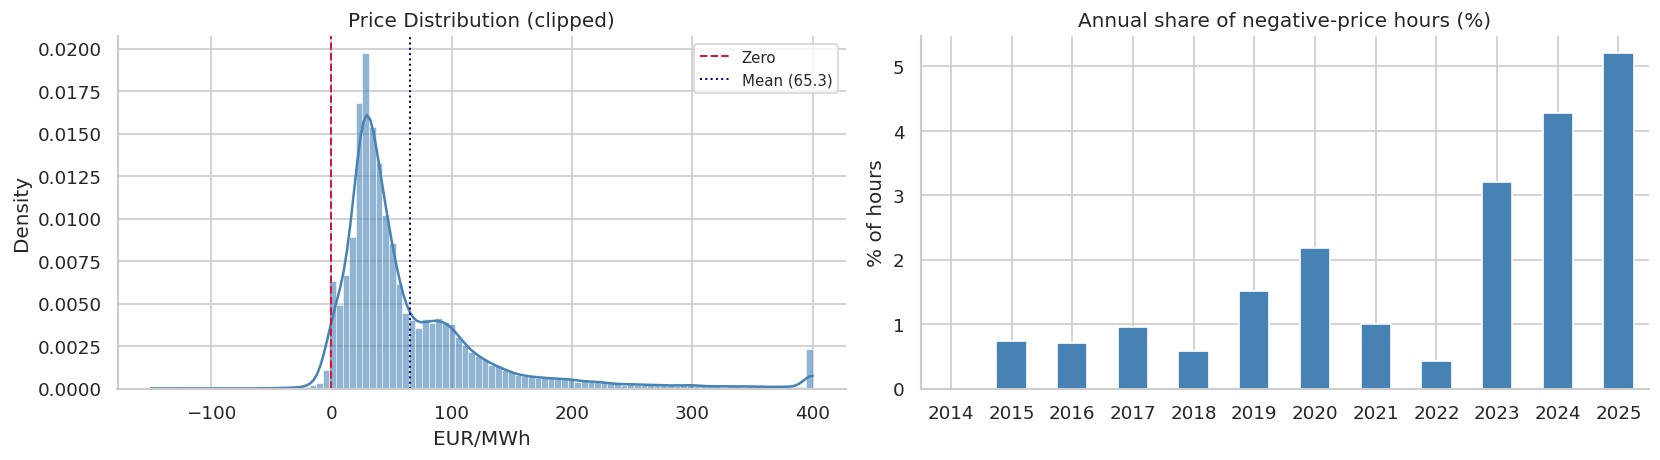

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
descriptive.plot_price_distribution(price, ax=axes[0], clip=(-150, 400))
descriptive.plot_negative_prices(price, ax=axes[1])
fig.tight_layout()

---
## 3 · Calendar Seasonality

Calendar effects are consistently selected by LASSO across all EPF studies (Uniejewski et al. 2018; Lago et al. 2021).  
The dual-peak intra-day profile (morning + evening ramp) and the winter premium are characteristic of DK1.

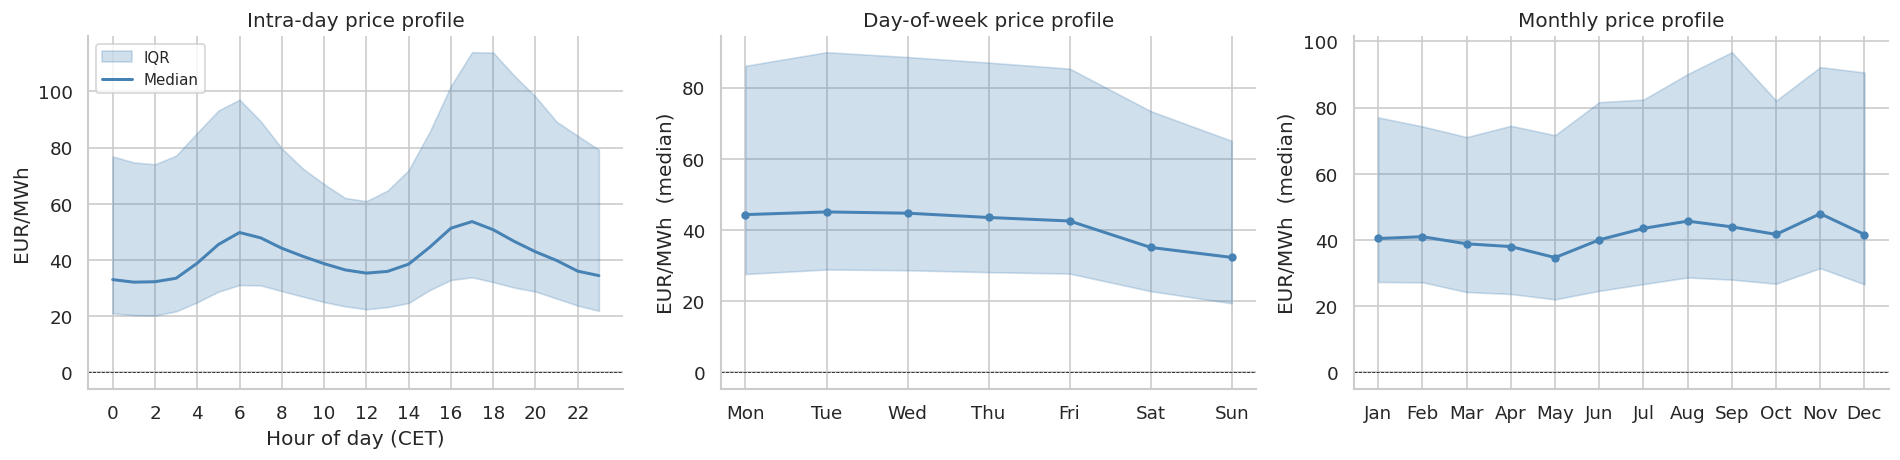

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
temporal.plot_hourly_profile(price, ax=axes[0])
temporal.plot_dow_profile(price, ax=axes[1])
temporal.plot_monthly_profile(price, ax=axes[2])
fig.tight_layout()

<Axes: title={'center': 'Median price by hour × month (EUR/MWh)'}, ylabel='Hour of day'>

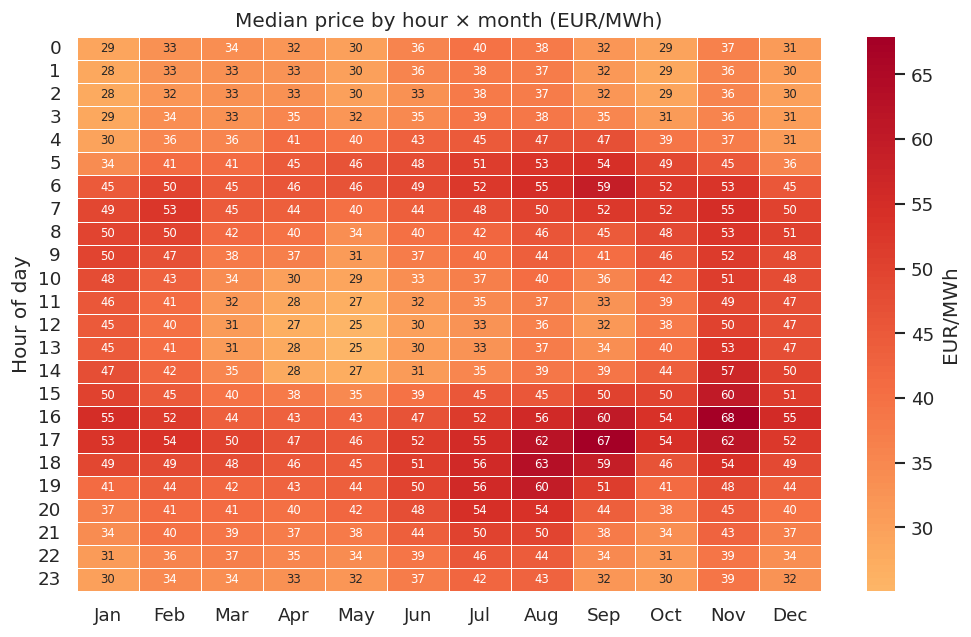

In [15]:
temporal.plot_heatmap_hour_month(price)

---
## 4 · Autocorrelation Structure

The LEAR benchmark (Lago et al. 2021) uses lags **d−1, d−2, d−3, d−7** (i.e. 24h, 48h, 72h, 168h).  
Liu et al. (2023) SHAP analysis ranks the **7-day lag** as the single most predictive feature for DK1,
driven by the weekly dispatch cycle and cross-Great-Belt synchronisation with DK2.

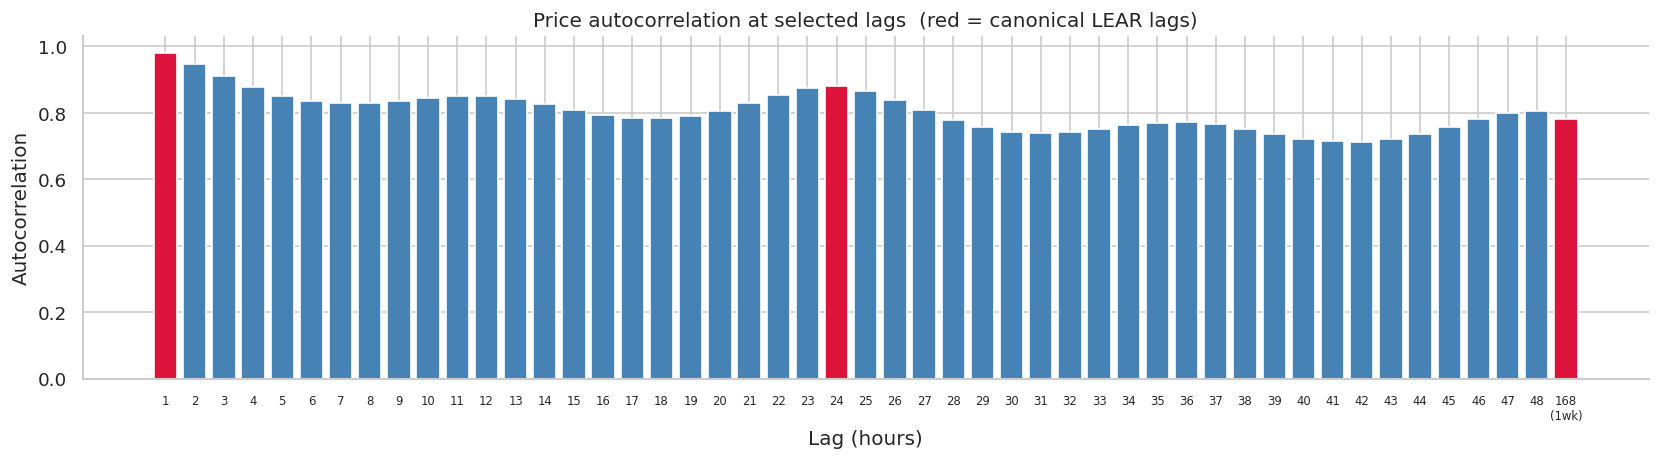

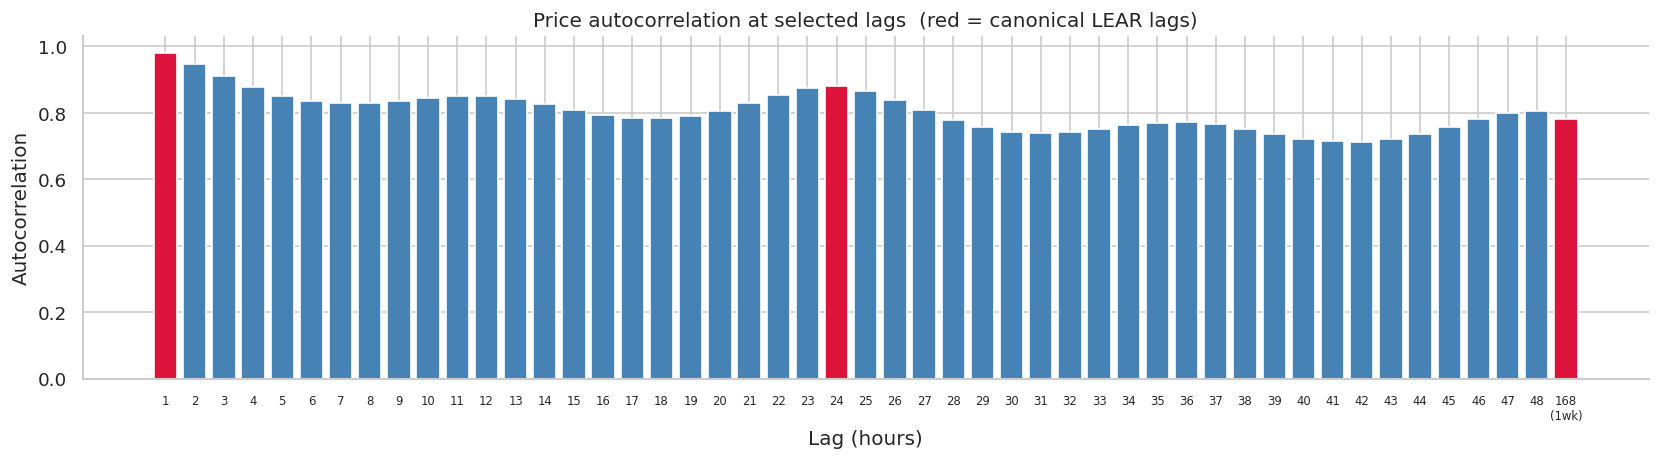

In [16]:
# Fast manual bar chart — avoids expensive statsmodels ACF for full series
temporal.plot_acf_manual(price)

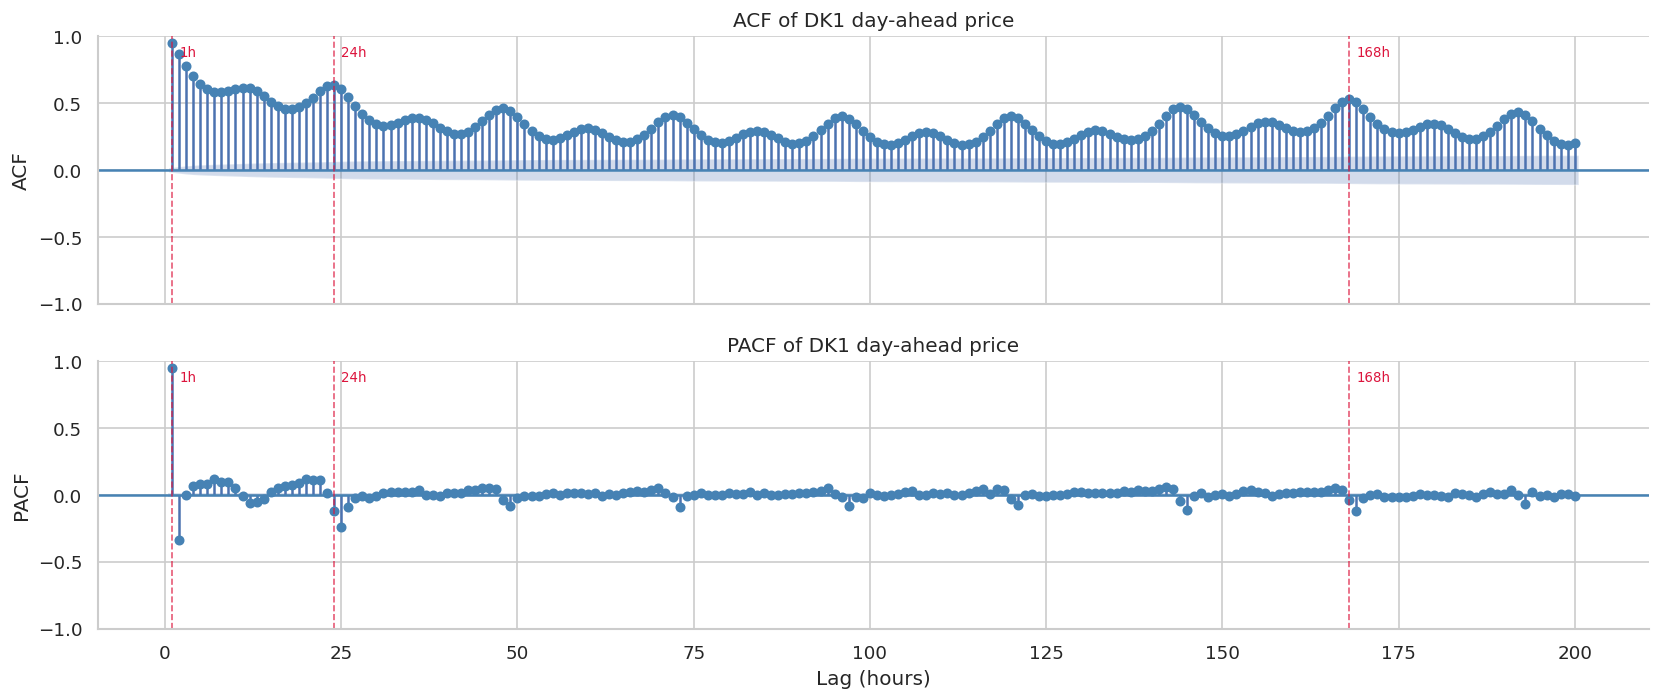

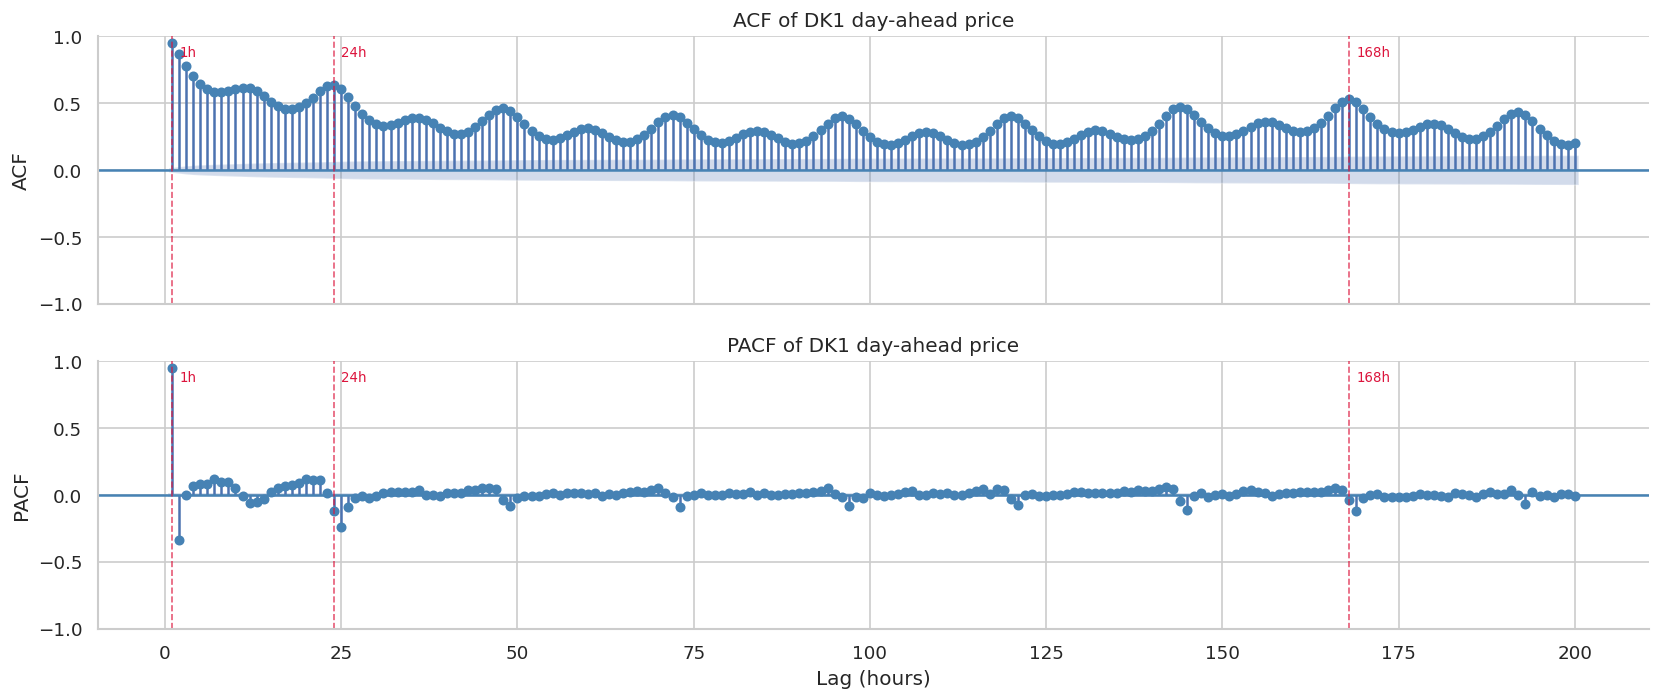

In [17]:
# Formal ACF / PACF (computed on a 2-year window for speed)
price_window = price.loc["2019":"2020"].dropna()
temporal.plot_acf_key_lags(price_window, max_lag=200)

---
## 5 · Wind Power — Rank 1 Predictor

DK1 has ~49% wind penetration (Becker & Blatt 2020).  
The wind-price relationship is **nonlinear**: prices plateau at high wind because surplus is exported
or absorbed by storage, but sufficiently high wind triggers negative prices (merit-order inversion).  
Jónsson et al. (2013) show that explicitly modelling this nonlinearity significantly improves forecasts.

The CSV exposes four wind signals per source (day-ahead forecast, intraday, current-day, actual),
enabling forecast-error analysis not available in the raw loader version.

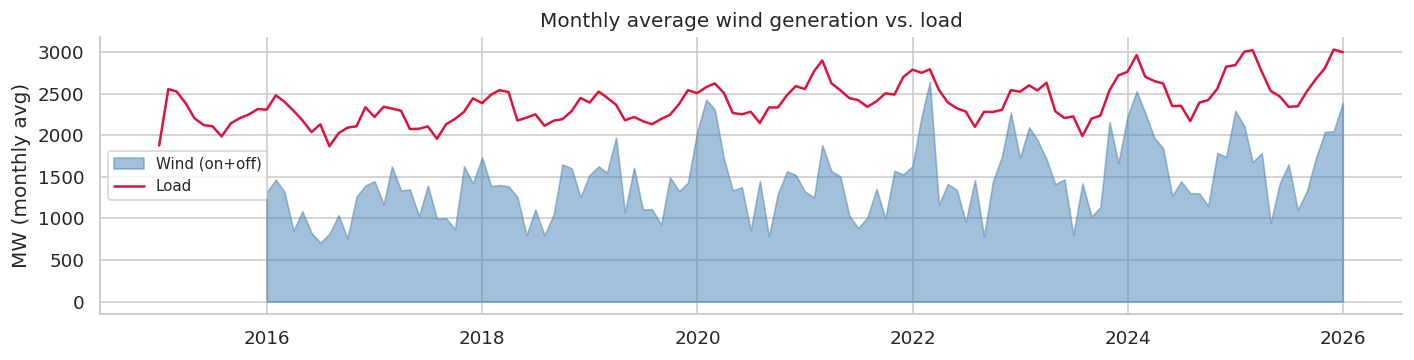

In [18]:
# Wind generation time series
fig, ax = plt.subplots(figsize=(14, 3))
wind_total_monthly = (wind_on_act + wind_off_act).resample("ME").mean()
load_monthly = load_actual.resample("ME").mean()
ax.fill_between(wind_total_monthly.index, wind_total_monthly.values, alpha=0.5,
                color="steelblue", label="Wind (on+off)")
ax.plot(load_monthly.index, load_monthly.values, color="crimson", lw=1.5, label="Load")
ax.set_ylabel("MW (monthly avg)")
ax.set_title("Monthly average wind generation vs. load")
ax.legend(fontsize=9)
sns.despine(ax=ax)

<Axes: title={'center': 'Monthly average wind penetration in DK1'}, ylabel='Wind / Load  (%)'>

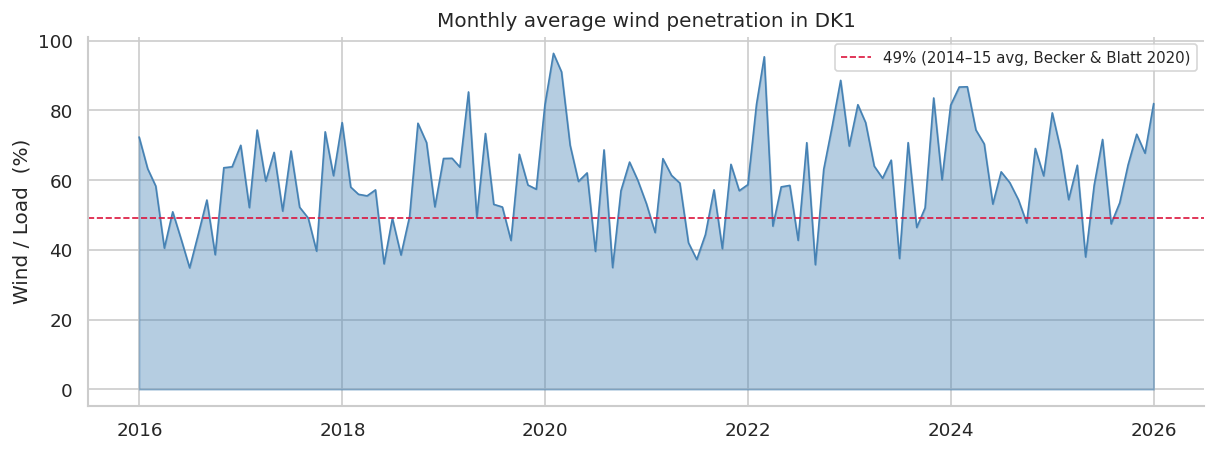

In [19]:
relationships.plot_wind_share_series(wind_on_act, wind_off_act, load_actual)

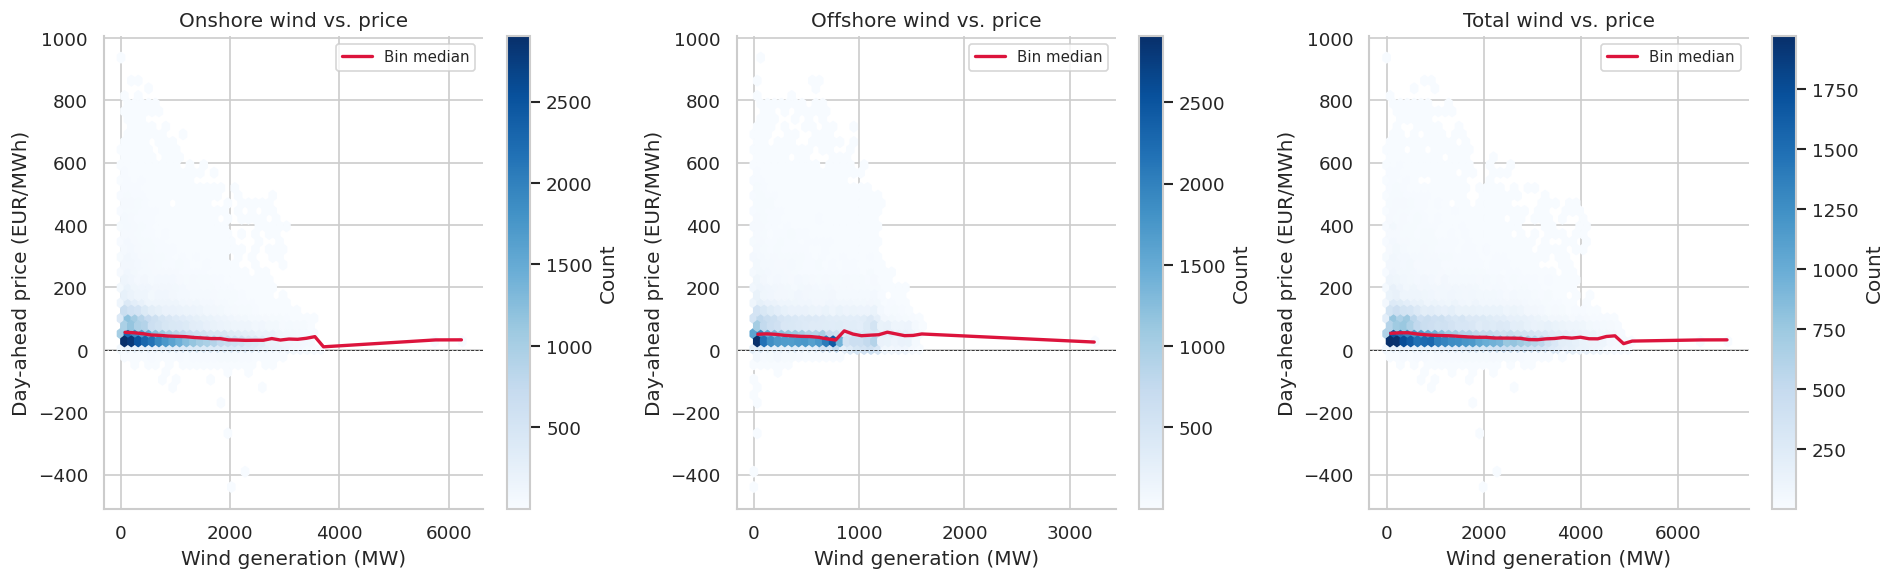

In [20]:
# Wind vs price scatter (hexbin density)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
relationships.plot_wind_price_scatter(price, wind_on_act, ax=axes[0])
axes[0].set_title("Onshore wind vs. price")
relationships.plot_wind_price_scatter(price, wind_off_act, ax=axes[1])
axes[1].set_title("Offshore wind vs. price")
relationships.plot_wind_price_scatter(price, wind_on_act + wind_off_act, ax=axes[2])
axes[2].set_title("Total wind vs. price")
fig.tight_layout()

### 5.1 Wind forecast error

The CSV provides multiple forecast vintages for wind (day-ahead, intraday, current-day).  
Forecast error is defined as `actual − forecast`.  Systematic biases in the DA forecast
directly translate into pricing errors (Jónsson et al. 2013).

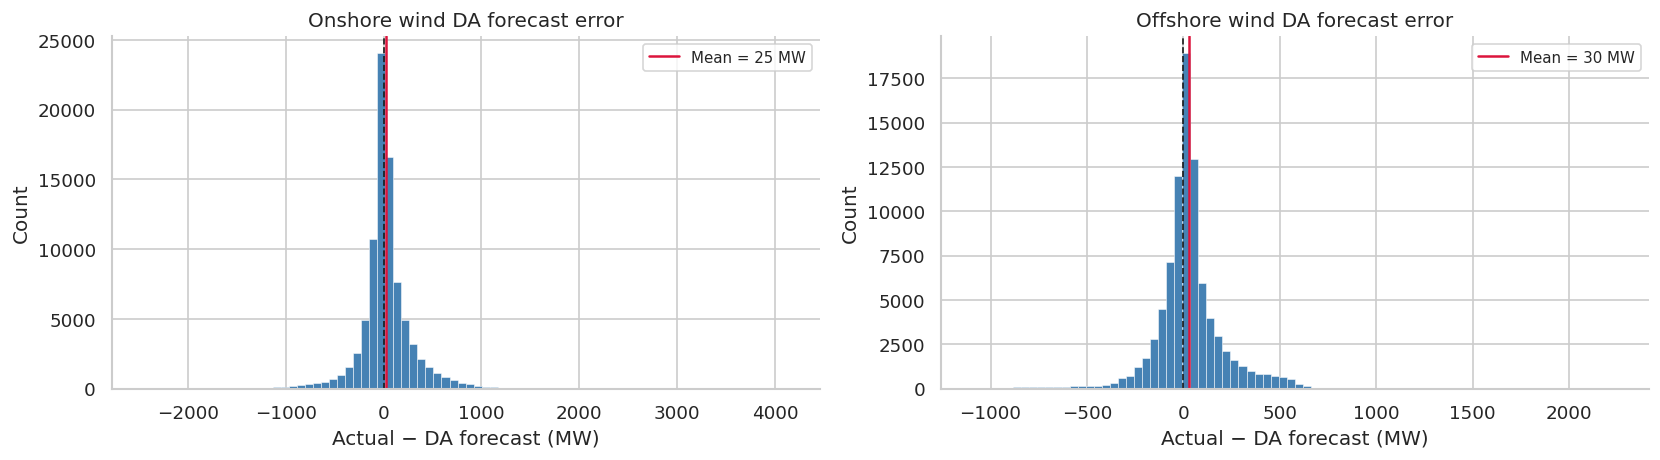

In [21]:
# Onshore wind forecast error: actual minus day-ahead forecast
wind_on_err = raw["wind_onshore_actual_mw"] - raw["wind_onshore_day_ahead_mw"]
wind_off_err = raw["wind_offshore_actual_mw"] - raw["wind_offshore_day_ahead_mw"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, err, label in zip(axes, [wind_on_err, wind_off_err], ["Onshore", "Offshore"]):
    err_clean = err.dropna()
    ax.hist(err_clean, bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="k", lw=1, ls="--")
    ax.axvline(err_clean.mean(), color="crimson", lw=1.5, ls="-",
               label=f"Mean = {err_clean.mean():.0f} MW")
    ax.set_xlabel("Actual − DA forecast (MW)")
    ax.set_ylabel("Count")
    ax.set_title(f"{label} wind DA forecast error")
    ax.legend(fontsize=9)
    sns.despine(ax=ax)
fig.tight_layout()

---
## 6 · Cross-Border Flows — Rank 3 Predictor

`hourly_features.csv` contains only **aggregate** cross-border flows (`gross_import_mw`, `gross_export_mw`,
`net_import_mw`), not per-partner breakdowns.  Li & Becker (2021) find the DK1↔Germany flow is among
the most predictive features; Liu et al. (2023) document a ~800 MW threshold on that interconnector.
Those partner-level analyses are available in `01_eda.ipynb`.

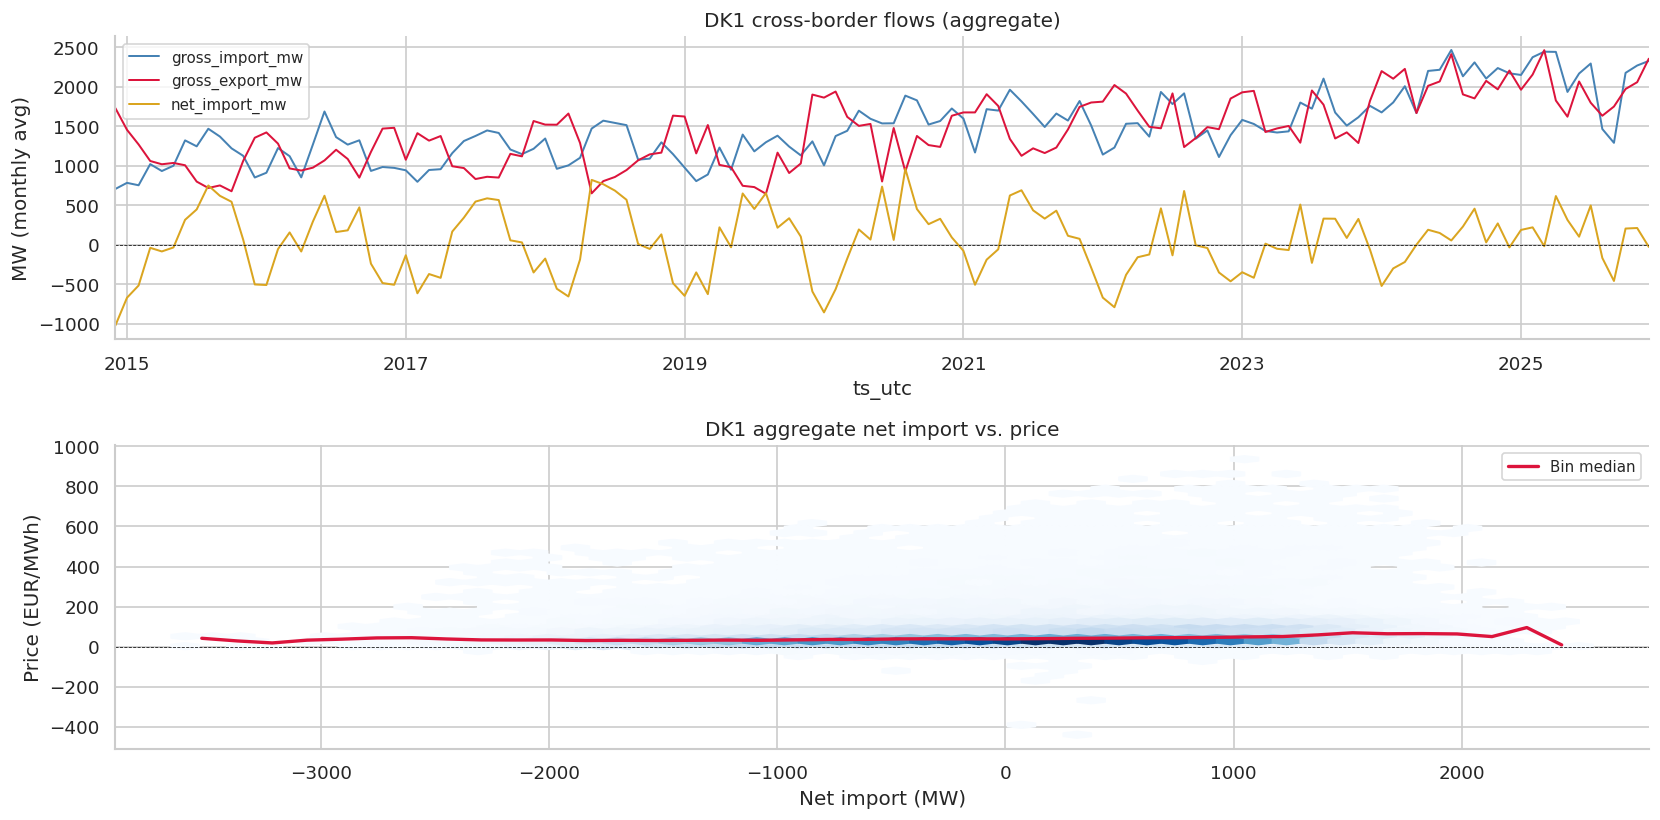

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Monthly average flows
flow_monthly = raw[["gross_import_mw", "gross_export_mw", "net_import_mw"]].resample("ME").mean()
flow_monthly.plot(ax=axes[0], lw=1.2, color=["steelblue", "crimson", "goldenrod"])
axes[0].axhline(0, color="k", lw=0.5, ls="--")
axes[0].set_ylabel("MW (monthly avg)")
axes[0].set_title("DK1 cross-border flows (aggregate)")
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

# Net import vs price scatter
df_fp = pd.concat([price.rename("price"), net_import.rename("net_import")], axis=1).dropna()
axes[1].hexbin(df_fp["net_import"], df_fp["price"], gridsize=50, cmap="Blues", mincnt=1)
# Bin median
df_s = df_fp.sort_values("net_import")
bins = pd.cut(df_s["net_import"], bins=40)
med = df_s.groupby(bins, observed=True)["price"].median()
bin_mid = [i.mid for i in med.index]
axes[1].plot(bin_mid, med.values, color="crimson", lw=2, label="Bin median")
axes[1].axhline(0, color="k", lw=0.5, ls="--")
axes[1].set_xlabel("Net import (MW)")
axes[1].set_ylabel("Price (EUR/MWh)")
axes[1].set_title("DK1 aggregate net import vs. price")
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

fig.tight_layout()

---
## 7 · Load Analysis — Rank 4 Predictor

Load is less dominant in DK1 than in thermal-dominated systems because renewable dispatch
shapes prices more than demand cycles. Nevertheless it is consistently retained by LASSO.

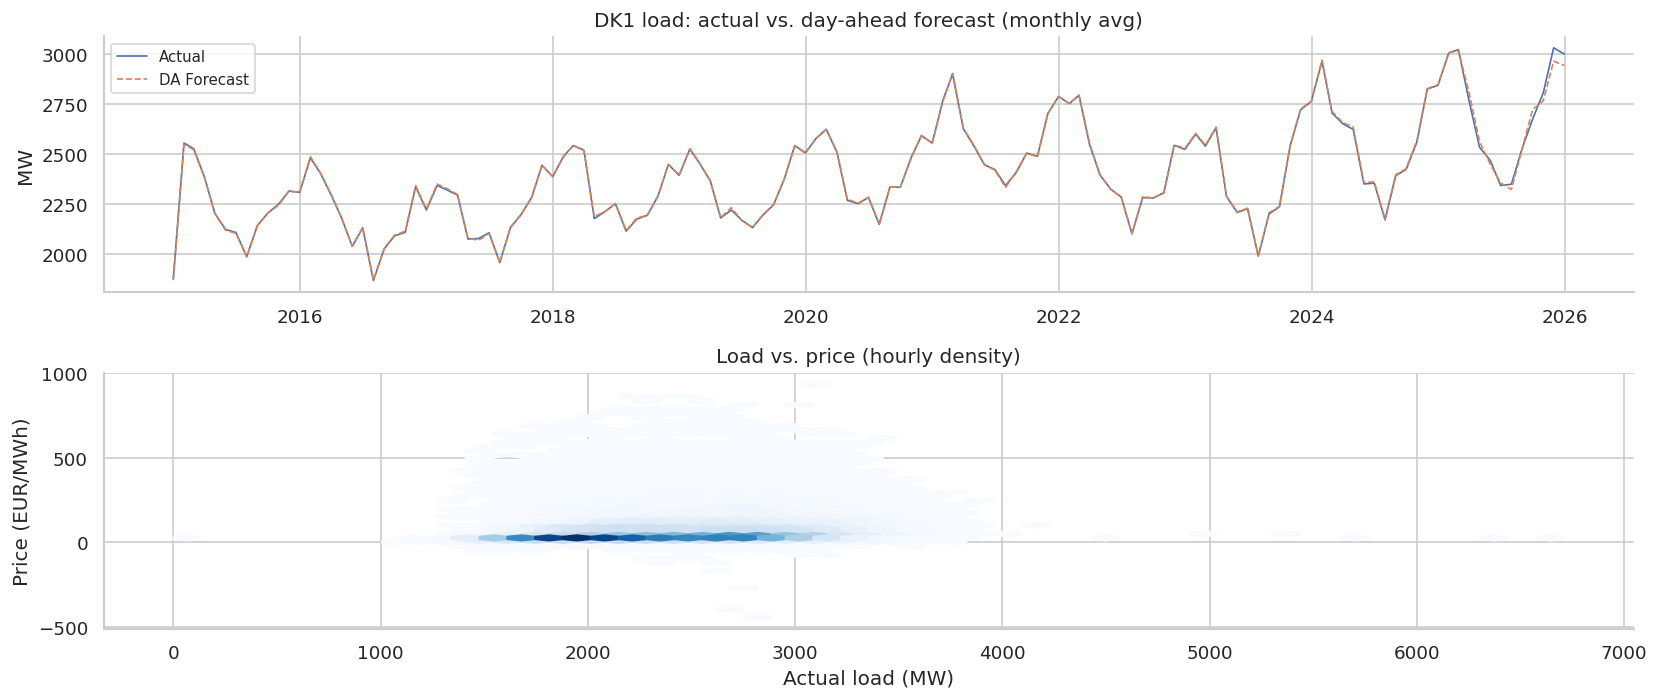

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Actual vs forecast
loads_monthly = raw[["actual_load_mw", "day_ahead_load_forecast_mw"]].resample("ME").mean()
axes[0].plot(loads_monthly.index, loads_monthly["actual_load_mw"], lw=1.0, label="Actual")
axes[0].plot(loads_monthly.index, loads_monthly["day_ahead_load_forecast_mw"],
             lw=1.0, ls="--", label="DA Forecast")
axes[0].set_ylabel("MW")
axes[0].set_title("DK1 load: actual vs. day-ahead forecast (monthly avg)")
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

# Load vs price scatter
df_lp = pd.concat([price.rename("price"), load_actual.rename("load")], axis=1).dropna()
axes[1].hexbin(df_lp["load"], df_lp["price"], gridsize=50, cmap="Blues", mincnt=1)
axes[1].set_xlabel("Actual load (MW)")
axes[1].set_ylabel("Price (EUR/MWh)")
axes[1].set_title("Load vs. price (hourly density)")
sns.despine(ax=axes[1])

fig.tight_layout()

---
## 8 · Commodity Prices — Rank 5–6 Predictors

Gas prices (TTF) surged from a moderate predictor to the dominant one during the 2021–22 energy crisis
(Tschora et al. 2022). CO2/EUA prices are positively linked with Nordic market risk (2024 Energy Economics).  
The CSV also includes financial variables (MSCI EU, EuroStoxx50, VIX, USD/EUR) and macro indicators
(CPI, GDP) not present in `01_eda`.

<Axes: title={'center': 'Commodity prices (z-score normalised)'}, ylabel='Z-score'>

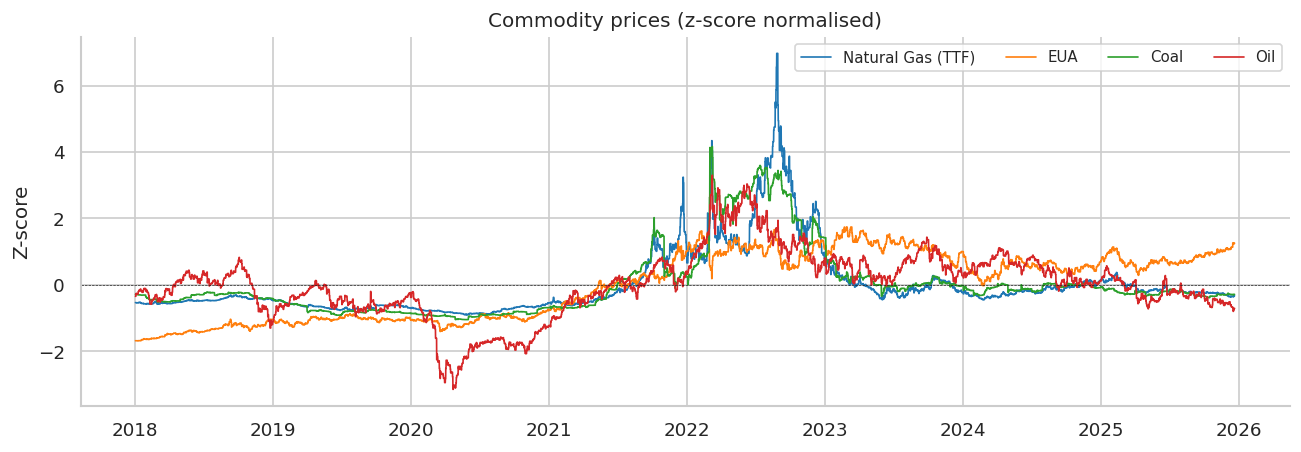

In [24]:
relationships.plot_commodities({"Natural Gas (TTF)": gas, "EUA": eua, "Coal": coal, "Oil": oil})

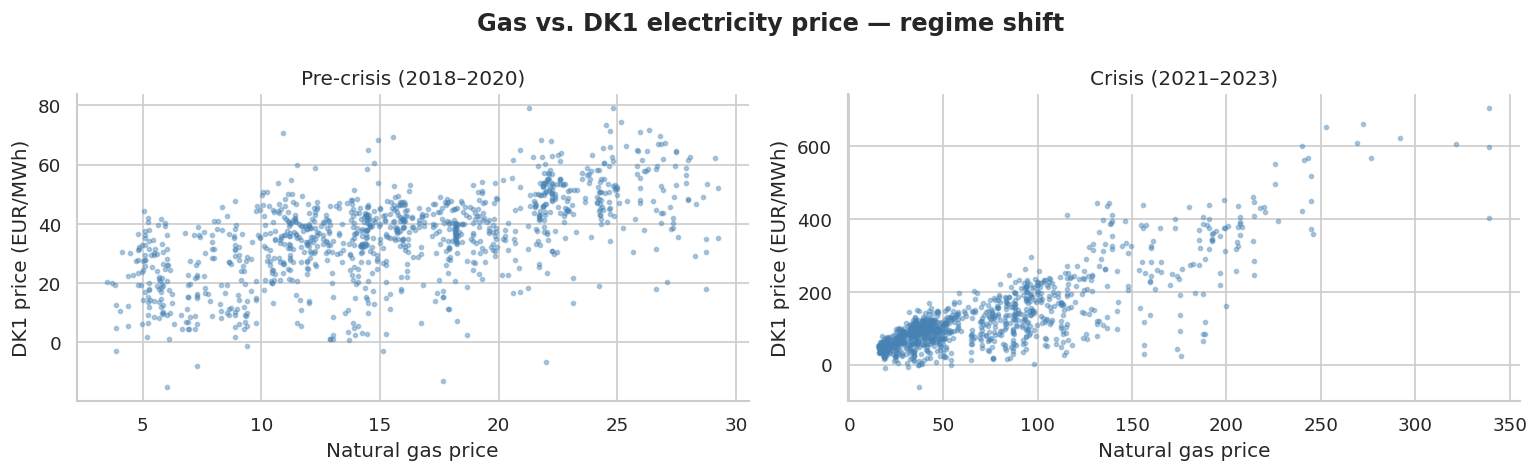

In [25]:
# Price vs gas scatter (daily averages)
price_daily = price.resample("D").mean()
gas_daily   = gas.resample("D").last()
df_pg = pd.concat([price_daily.rename("price"), gas_daily.rename("gas")], axis=1).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, era, label in zip(
    axes,
    [slice("2018", "2020"), slice("2021", "2023")],
    ["Pre-crisis (2018–2020)", "Crisis (2021–2023)"],
):
    sub = df_pg.loc[era]
    ax.scatter(sub["gas"], sub["price"], alpha=0.4, s=6, color="steelblue")
    ax.set_xlabel("Natural gas price")
    ax.set_ylabel("DK1 price (EUR/MWh)")
    ax.set_title(label)
    sns.despine(ax=ax)
fig.suptitle("Gas vs. DK1 electricity price — regime shift", fontweight="bold")
fig.tight_layout()

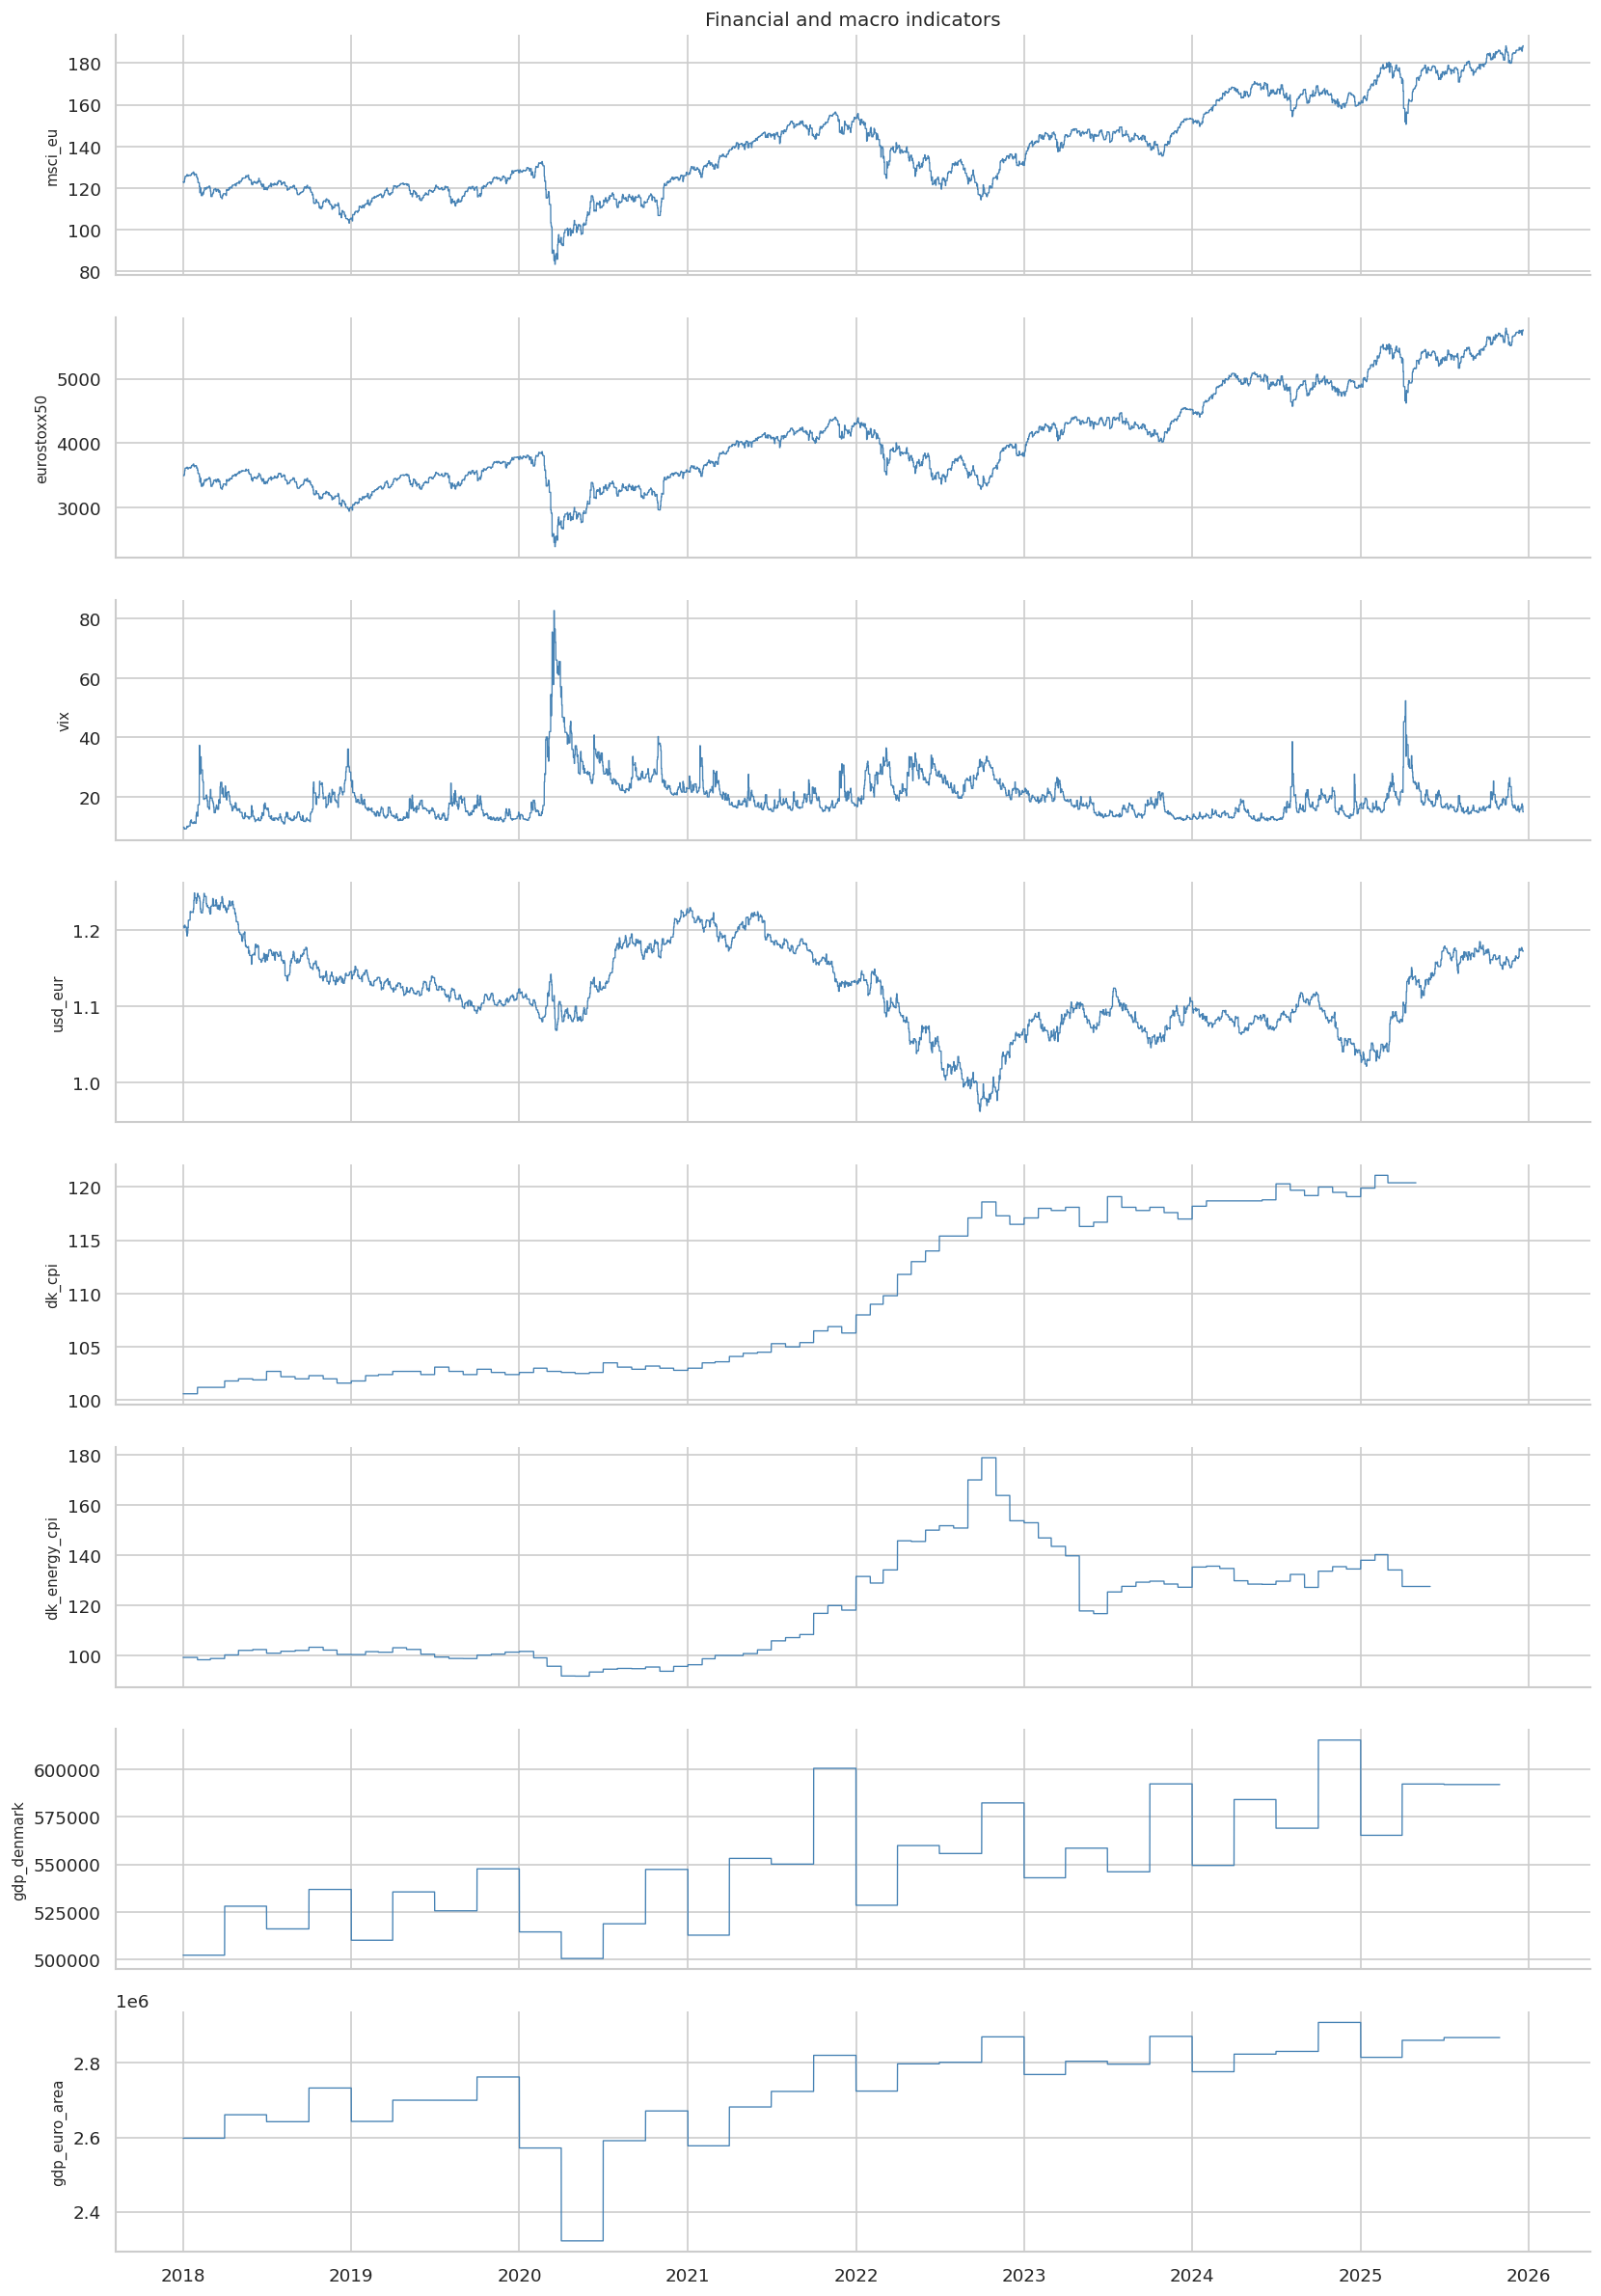

In [26]:
# Financial & macro variables (additional to 01_eda)
macro_cols = [c for c in ["msci_eu", "eurostoxx50", "vix", "usd_eur",
                           "dk_cpi", "dk_energy_cpi", "gdp_denmark", "gdp_euro_area"]
              if c in raw.columns]

fig, axes = plt.subplots(len(macro_cols), 1, figsize=(14, 2.5 * len(macro_cols)), sharex=True)
if len(macro_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, macro_cols):
    s = raw[col].dropna()
    ax.plot(s.index, s.values, lw=0.8, color="steelblue")
    ax.set_ylabel(col, fontsize=9)
    sns.despine(ax=ax)
axes[0].set_title("Financial and macro indicators")
fig.tight_layout()

---
## 9 · Solar Generation

Solar ranks 11th in the literature — still a small share of DK1 generation but growing.  
Its effect is already captured implicitly through hourly load profiles.

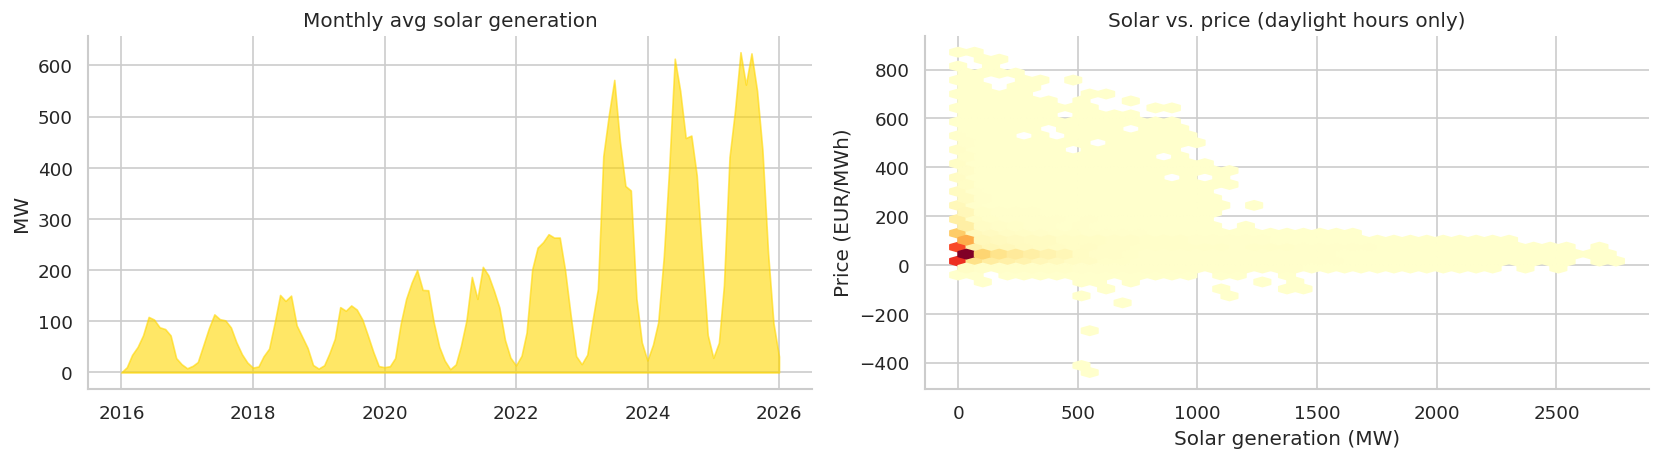

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

solar_monthly = solar_act.resample("ME").mean()
axes[0].fill_between(solar_monthly.index, solar_monthly.values, alpha=0.6, color="gold")
axes[0].set_ylabel("MW")
axes[0].set_title("Monthly avg solar generation")
sns.despine(ax=axes[0])

# Solar vs price — merit-order displacement at midday
df_sp = pd.concat([price.rename("price"), solar_act.rename("solar")], axis=1).dropna()
df_sp = df_sp[df_sp["solar"] > 0]
axes[1].hexbin(df_sp["solar"], df_sp["price"], gridsize=40, cmap="YlOrRd", mincnt=1)
axes[1].set_xlabel("Solar generation (MW)")
axes[1].set_ylabel("Price (EUR/MWh)")
axes[1].set_title("Solar vs. price (daylight hours only)")
sns.despine(ax=axes[1])
fig.tight_layout()

---
## 10 · Climate Variables

Karabiber & Xydis (2019) found that **excluding temperature improved DK1 forecasts** — its effect is
already captured through wind and load.  
We include wind speed (Esbjerg Airport) as a proxy for the wind-generation signal.  
The CSV also provides precipitation (`rr_daily`) and sunshine hours (`ss_daily`).

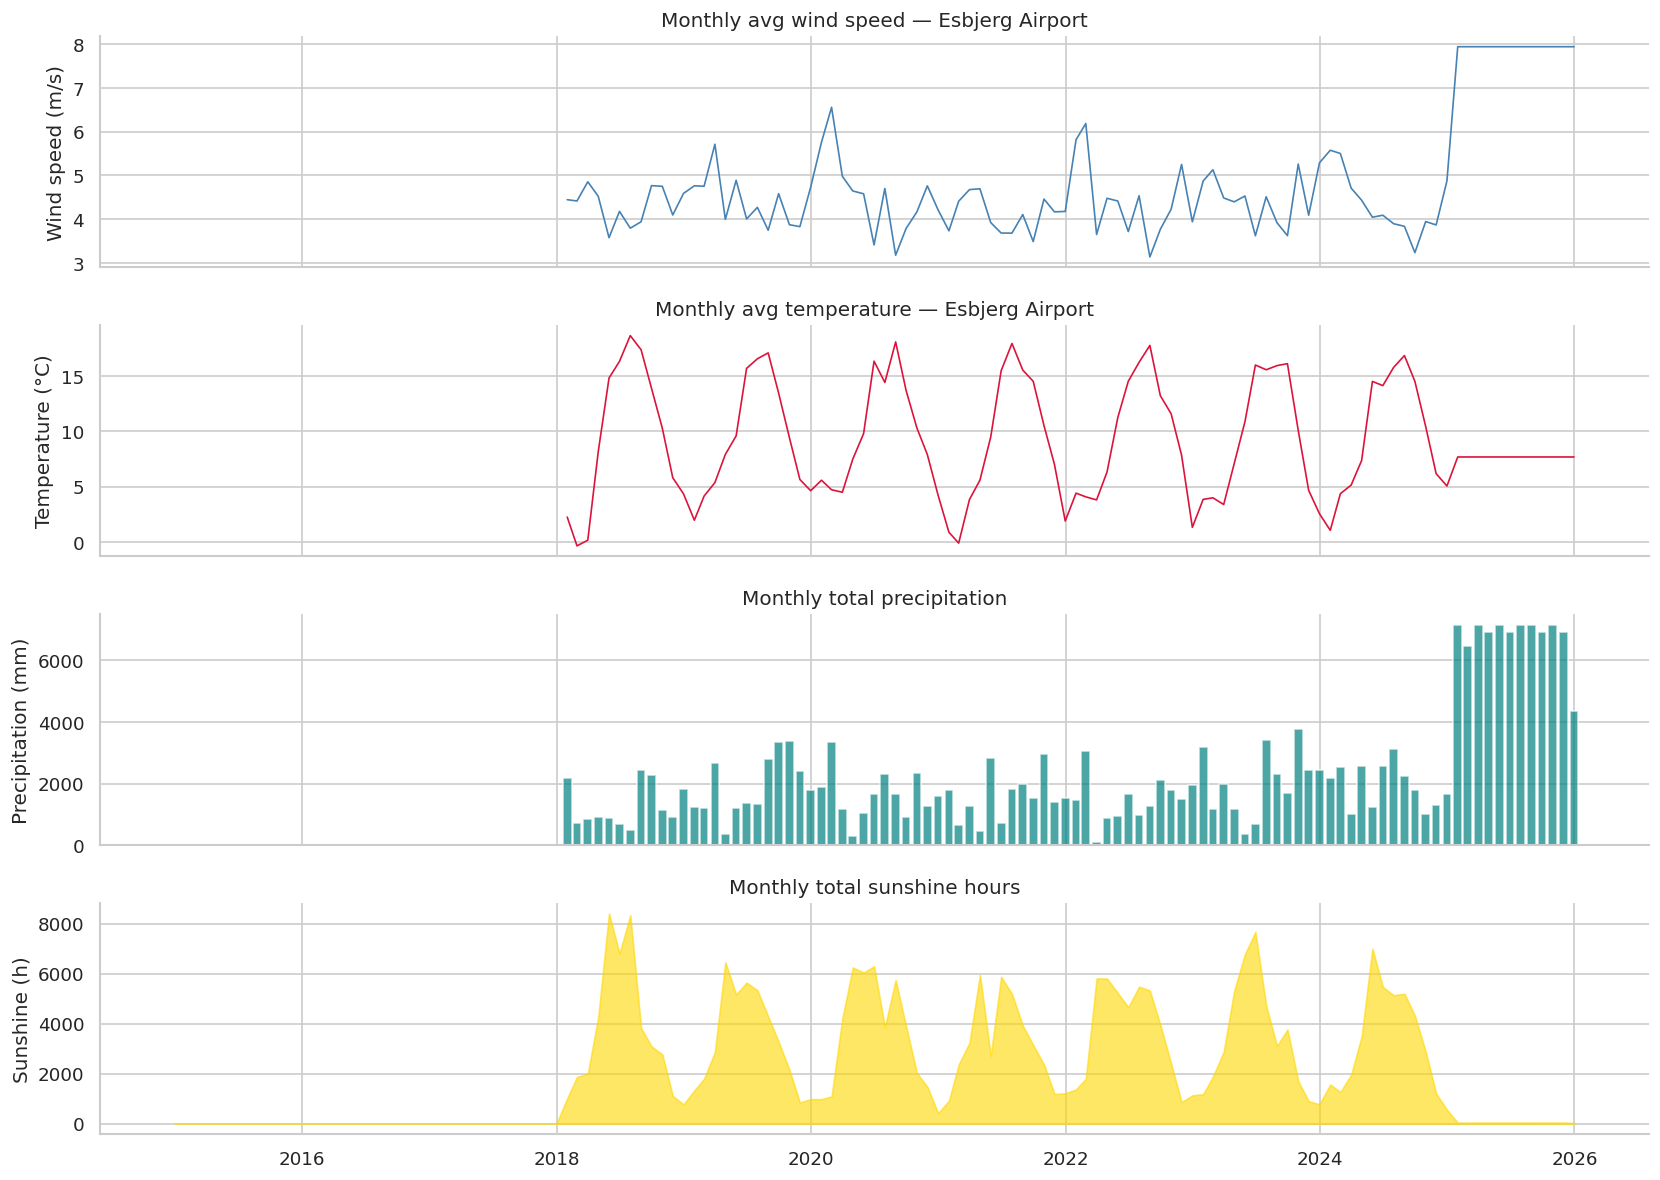

In [30]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# Wind speed (0.1 m/s → m/s)
fg_ms = (fg / 10).resample("ME").mean()
axes[0].plot(fg_ms.index, fg_ms.values, color="steelblue", lw=1.0)
axes[0].set_ylabel("Wind speed (m/s)")
axes[0].set_title("Monthly avg wind speed — Esbjerg Airport")
sns.despine(ax=axes[0])

# Temperature (0.1 °C → °C)
tg_c = (tg / 10).resample("ME").mean()
axes[1].plot(tg_c.index, tg_c.values, color="crimson", lw=1.0)
axes[1].set_ylabel("Temperature (°C)")
axes[1].set_title("Monthly avg temperature — Esbjerg Airport")
sns.despine(ax=axes[1])

# Precipitation (rr_daily, 0.1 mm → mm)
if "rr_daily" in raw.columns:
    rr_mm = (raw["rr_daily"] / 10).resample("ME").sum()
    axes[2].bar(rr_mm.index, rr_mm.values, width=25, color="teal", alpha=0.7)
    axes[2].set_ylabel("Precipitation (mm)")
    axes[2].set_title("Monthly total precipitation")
    sns.despine(ax=axes[2])

# Sunshine hours (ss_daily, 0.1 h → h)
if "ss_daily" in raw.columns:
    ss_h = (raw["ss_daily"] / 10).resample("ME").sum()
    axes[3].fill_between(ss_h.index, ss_h.values, alpha=0.6, color="gold")
    axes[3].set_ylabel("Sunshine (h)")
    axes[3].set_title("Monthly total sunshine hours")
    sns.despine(ax=axes[3])

fig.tight_layout()

---
## 11 · Correlation Matrix

Spearman correlations on daily-averaged variables confirm the literature ranking:
wind is the strongest driver of price suppression; gas/EUA co-move with prices post-2021.

In [31]:
# Build daily feature matrix from the CSV columns
hourly_for_daily = raw[[
    "day_ahead_price_eur_mwh",
    "wind_onshore_actual_mw",
    "wind_offshore_actual_mw",
    "solar_actual_mw",
    "actual_load_mw",
    "net_import_mw",
]].resample("D").mean()

daily_comm = raw[["gas_price", "eua_price", "coal_price", "oil_price"]].resample("D").last()
daily_climate = (raw[["fg_daily", "tg_daily"]] / 10).resample("D").mean()

feat_df = hourly_for_daily.join(daily_comm, how="left").join(daily_climate, how="left")
feat_df["wind_total"] = feat_df["wind_onshore_actual_mw"] + feat_df["wind_offshore_actual_mw"]

feat_df = feat_df.rename(columns={
    "day_ahead_price_eur_mwh": "price",
    "wind_onshore_actual_mw": "wind_onshore",
    "wind_offshore_actual_mw": "wind_offshore",
    "solar_actual_mw": "solar",
    "actual_load_mw": "load",
    "net_import_mw": "net_import",
    "fg_daily": "wind_speed_obs",
    "tg_daily": "temp_obs",
})

print(f"Feature matrix: {feat_df.shape[0]} days × {feat_df.shape[1]} features")
feat_df.describe().round(1)

Feature matrix: 4007 days × 13 features


,price,wind_onshore,wind_offshore,solar,load,net_import,gas_price,eua_price,coal_price,oil_price,wind_speed_obs,temp_obs,wind_total
count,4007.0,3642.0,3642.0,3642.0,4007.0,4007.0,2909.0,2909.0,2909.0,2909.0,2910.0,2910.0,3642.0
mean,66.6,928.2,522.0,155.7,2398.1,47.2,42.3,53.3,119.1,72.4,4.8,9.1,1450.2
std,72.4,668.9,329.1,180.0,323.2,767.1,42.6,27.0,76.7,16.8,1.9,5.7,962.0
min,-60.5,22.2,3.8,0.0,1570.0,-2182.3,3.5,7.7,38.6,19.3,1.2,-8.4,32.1
25%,27.7,369.4,245.5,31.2,2183.6,-496.7,17.9,25.1,68.5,64.0,3.3,5.2,624.7
50%,41.8,776.9,492.7,89.8,2388.3,89.8,30.6,61.9,100.4,72.9,4.4,7.7,1299.9
75%,80.4,1347.0,744.4,197.0,2615.4,636.9,44.1,77.4,122.6,82.1,6.1,13.9,2126.2
max,705.4,3377.9,1504.7,1103.3,3478.6,1829.9,339.2,100.3,438.4,128.0,11.5,24.3,4568.7


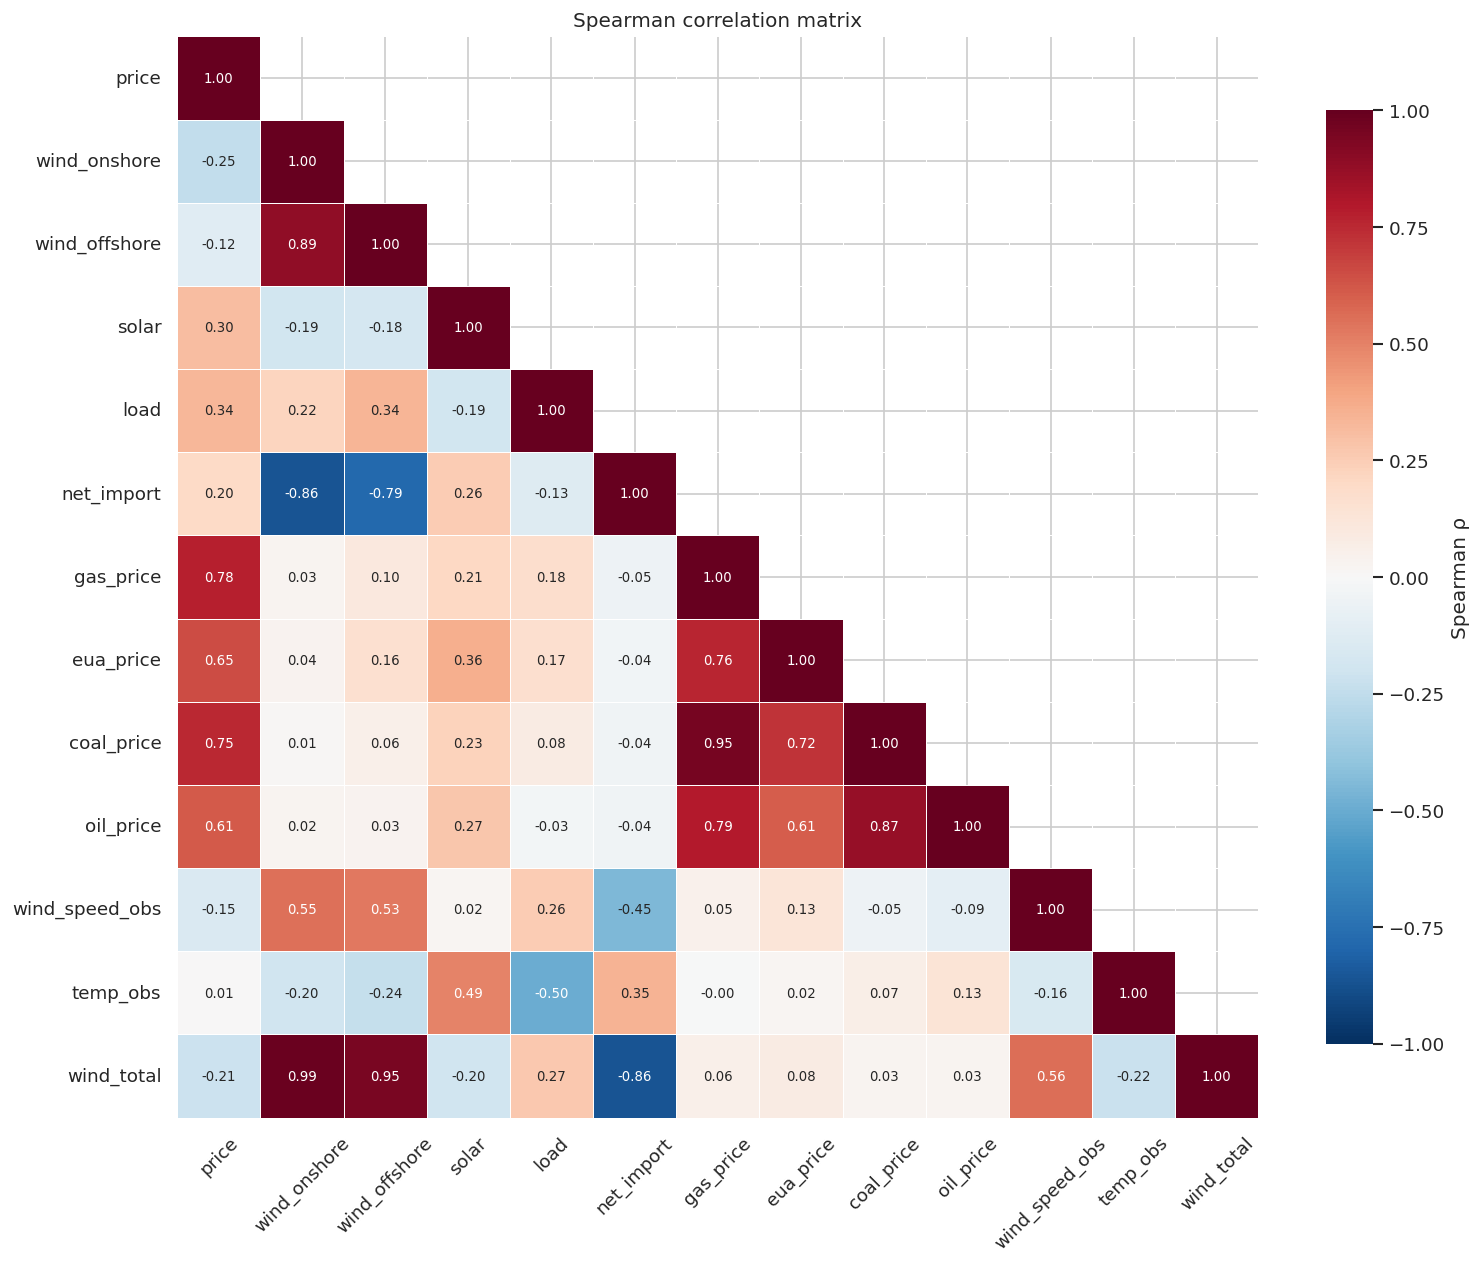

In [32]:
fig, ax = plt.subplots(figsize=(13, 11))
relationships.plot_correlation_matrix(feat_df, method="spearman", ax=ax)
fig.tight_layout()

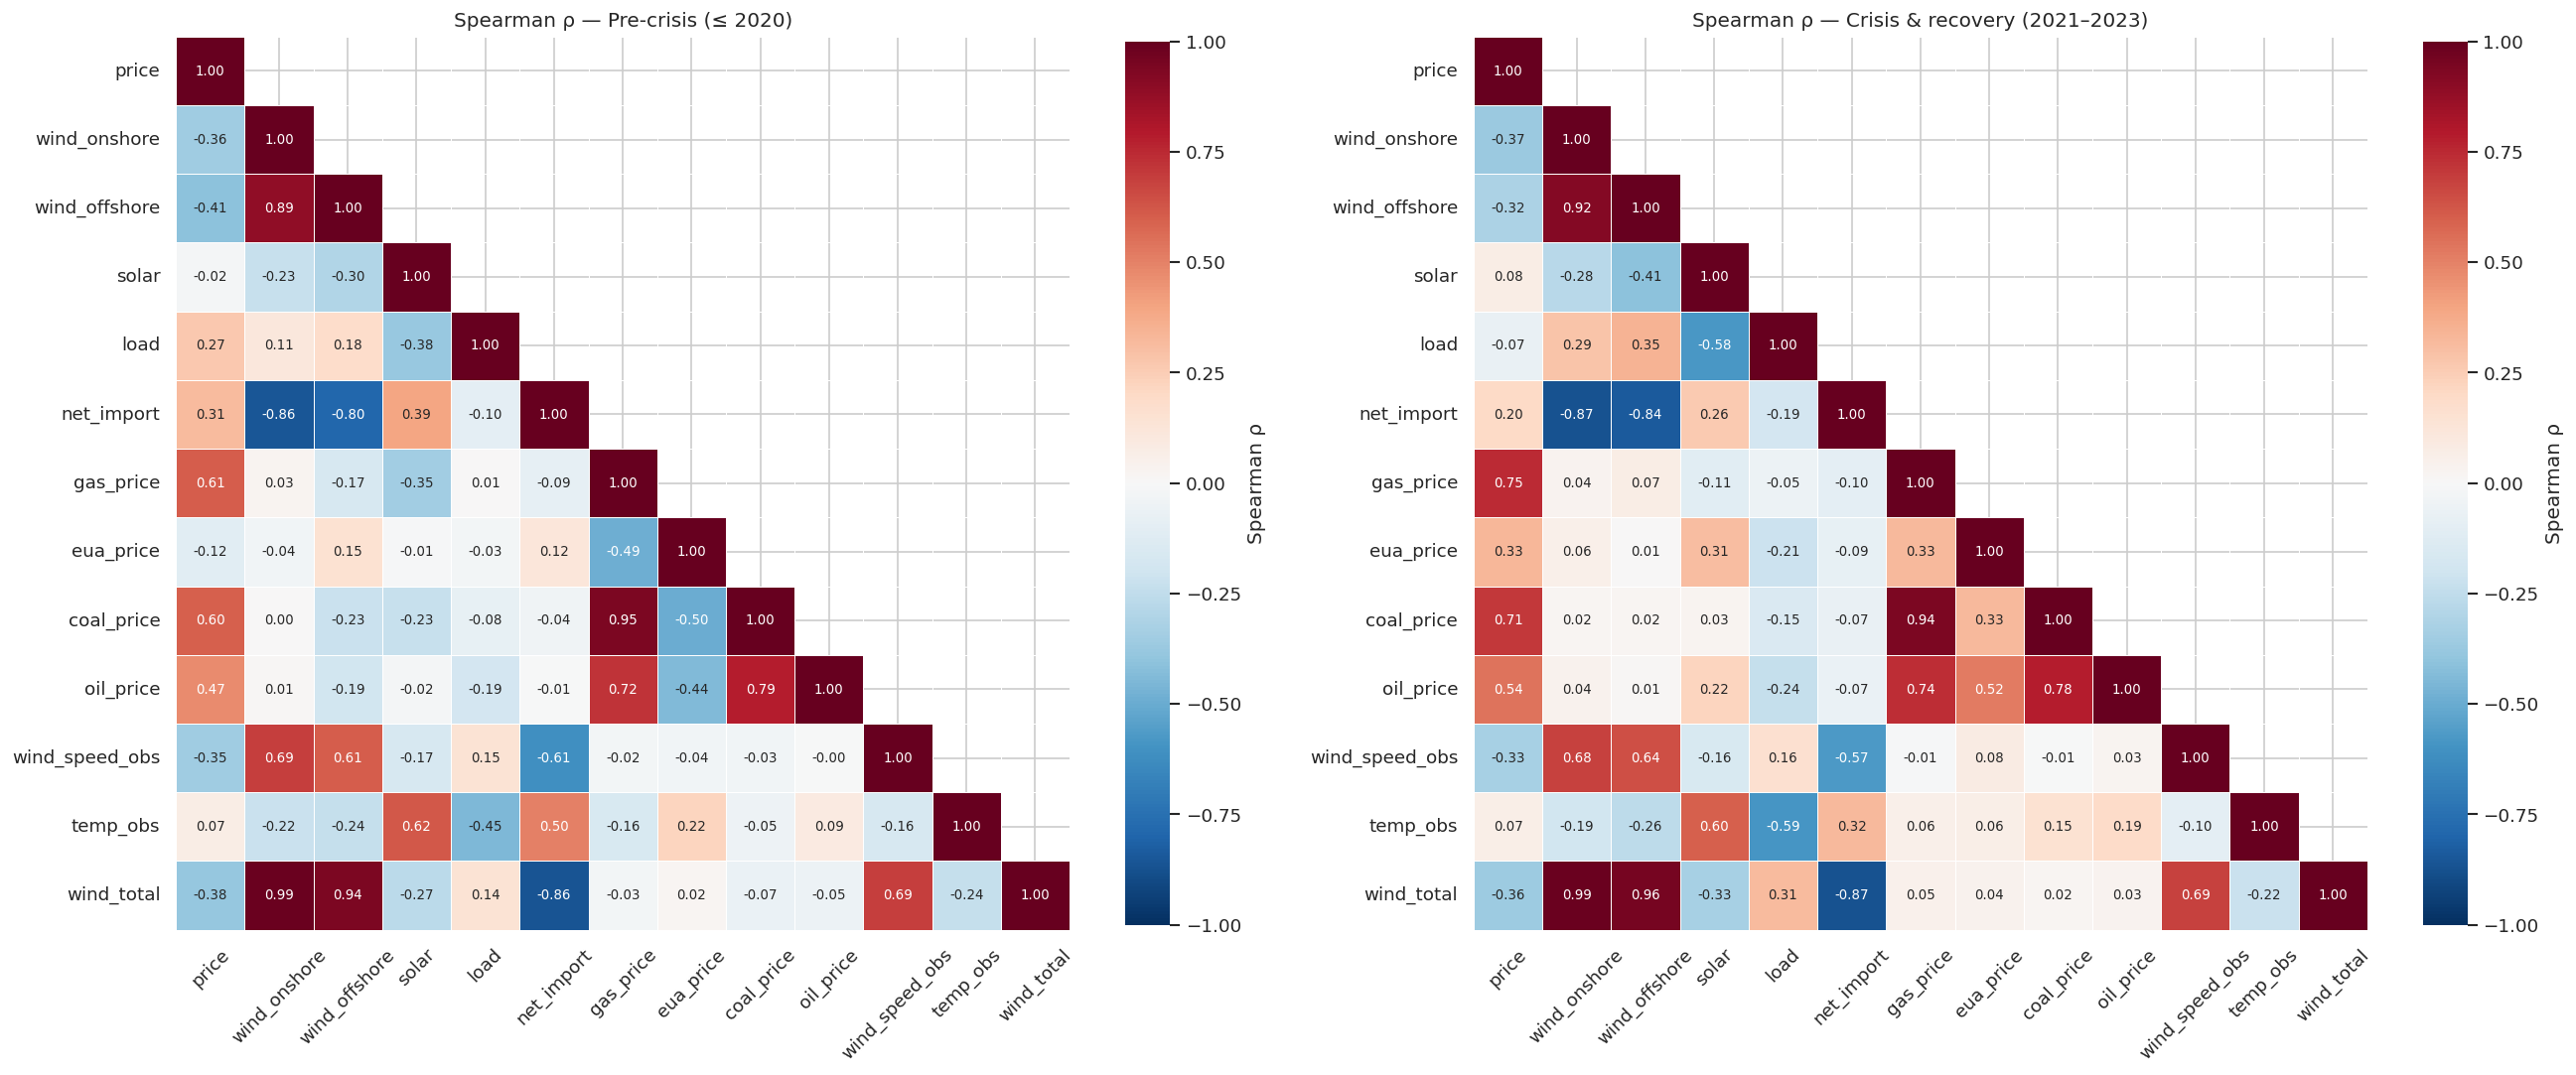

In [33]:
# Split: pre-crisis vs crisis to show feature-importance regime shift
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
relationships.plot_correlation_matrix(
    feat_df.loc[:"2020-12-31"].dropna(how="all"), method="spearman", ax=axes[0]
)
axes[0].set_title("Spearman ρ — Pre-crisis (≤ 2020)")
relationships.plot_correlation_matrix(
    feat_df.loc["2021-01-01":"2023-12-31"].dropna(how="all"), method="spearman", ax=axes[1]
)
axes[1].set_title("Spearman ρ — Crisis & recovery (2021–2023)")
fig.tight_layout()

---
## 12 · Key EDA Findings Summary

| Finding | Evidence |
|---------|----------|
| Price has strong weekly autocorrelation (lag 168h) | ACF plot |
| Negative-price frequency varies widely by year, highest when wind is high | Descriptive stats |
| Wind shows a nonlinear, inverting relationship with price | Wind–price scatter |
| DA wind forecast is systematically biased — see error distributions | §5.1 |
| Aggregate net import has a weaker per-unit price relationship than per-partner flows | §6 |
| Gas emerged as a dominant price driver only post-2021 | Regime-split correlation matrix |
| Load and solar have moderate, mostly linear correlations with price | Correlation matrix |
| Temperature / wind speed at Esbjerg proxies wind output | Climate plots |

**Differences vs. `01_eda.ipynb`:**
- Per-partner cross-border flows not available → replaced with aggregate net import.
- CSV adds coal, oil, financial (MSCI EU, EuroStoxx50, VIX, USD/EUR) and macro (CPI, GDP) columns.
- CSV adds multiple forecast vintages per renewable source, enabling forecast-error analysis (§5.1).
- Climate series (`tg_daily`, `fg_daily`, `rr_daily`, `ss_daily`) are already daily-granularity in the CSV.